# Notebook 4 — XGBoost Model
Trains XGBoost using weather_anomaly_score (from Isolation Forest) + lstm_disruption_prob (from LSTM) as features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

DATA_DIR   = '../datasets/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)
print('Imports done.')

Imports done.


In [2]:
# Load final_dataset — has weather_anomaly_score + lstm_disruption_prob already in it
df = pd.read_csv(DATA_DIR + 'final_dataset.csv', parse_dates=['order_date'])
print(f'Loaded final_dataset: {df.shape}')
print('Columns:', df.columns.tolist())

Loaded final_dataset: (8000, 37)
Columns: ['order_id', 'order_date', 'supplier_name', 'supplier_city', 'destination_city', 'product_category', 'transport_mode', 'distance_km', 'promised_delivery_days', 'actual_delivery_days', 'delay_days', 'shipment_cost_inr', 'quantity_units', 'disruption_cause', 'disruption_label', 'rainfall_mm', 'temperature_celsius', 'wind_speed_kmh', 'severity_score', 'weather_anomaly_score', 'sentiment_score', 'disruption_signal', 'composite_risk_score', 'delivery_reliability_score', 'regional_risk_index', 'strike_incidents_3yr', 'financial_stability_score', 'historical_disruption_count', 'rolling_7d_delay', 'rolling_14d_delay', 'lag1_delay', 'lag2_delay', 'transport_mode_enc', 'product_category_enc', 'supplier_city_enc', 'destination_city_enc', 'lstm_disruption_prob']


In [3]:
# XGBoost features — includes both Isolation Forest and LSTM outputs
FEATURES = [
    # Shipment details
    'distance_km', 'promised_delivery_days', 'quantity_units',
    # Weather (raw + Isolation Forest anomaly flag)
    'rainfall_mm', 'temperature_celsius', 'wind_speed_kmh',
    'severity_score', 'weather_anomaly_score',
    # Sentiment from D3
    'sentiment_score', 'disruption_signal',
    # Supplier risk from D4
    'composite_risk_score', 'delivery_reliability_score',
    'regional_risk_index', 'strike_incidents_3yr', 'financial_stability_score',
    # Historical context from D5
    'historical_disruption_count',
    # Engineered time features
    'rolling_7d_delay', 'rolling_14d_delay', 'lag1_delay', 'lag2_delay',
    # Encoded categoricals
    'transport_mode_enc', 'product_category_enc',
    'supplier_city_enc', 'destination_city_enc',
    # LSTM output — time-series disruption probability
    'lstm_disruption_prob'
]

TARGET = 'disruption_label'

missing_feats = [f for f in FEATURES if f not in df.columns]
if missing_feats:
    print(f'WARNING — missing columns: {missing_feats}')
else:
    print(f'All {len(FEATURES)} features found. ✅')

All 25 features found. ✅


In [4]:
# 80/20 positional split (works on any date range)
df = df.sort_values('order_date').reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Date range train: {train["order_date"].min().date()} → {train["order_date"].max().date()}')
print(f'Date range test : {test["order_date"].min().date()} → {test["order_date"].max().date()}')
print(f'Train disruption rate: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

Train: (6400, 25)  |  Test: (1600, 25)
Date range train: 2021-01-01 → 2023-03-10
Date range test : 2023-03-11 → 2023-09-28
Train disruption rate: 0.517  |  Test: 0.455


In [5]:
# Train XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print('XGBoost trained.')

XGBoost trained.


In [6]:
# Evaluate
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print('── XGBoost Evaluation ──')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}')

── XGBoost Evaluation ──
  Accuracy  : 0.9106
  Precision : 0.8834
  Recall    : 0.9258
  F1-Score  : 0.9041
  AUC-ROC   : 0.9793


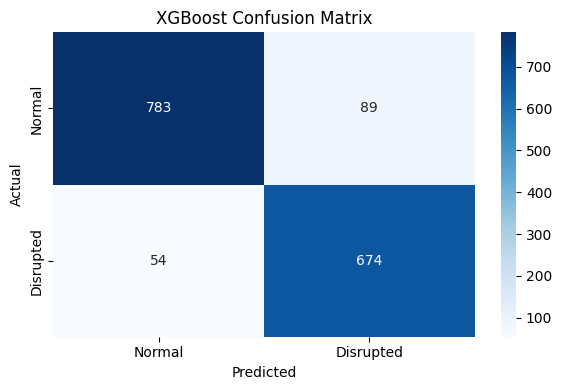

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Disrupted'],
            yticklabels=['Normal','Disrupted'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

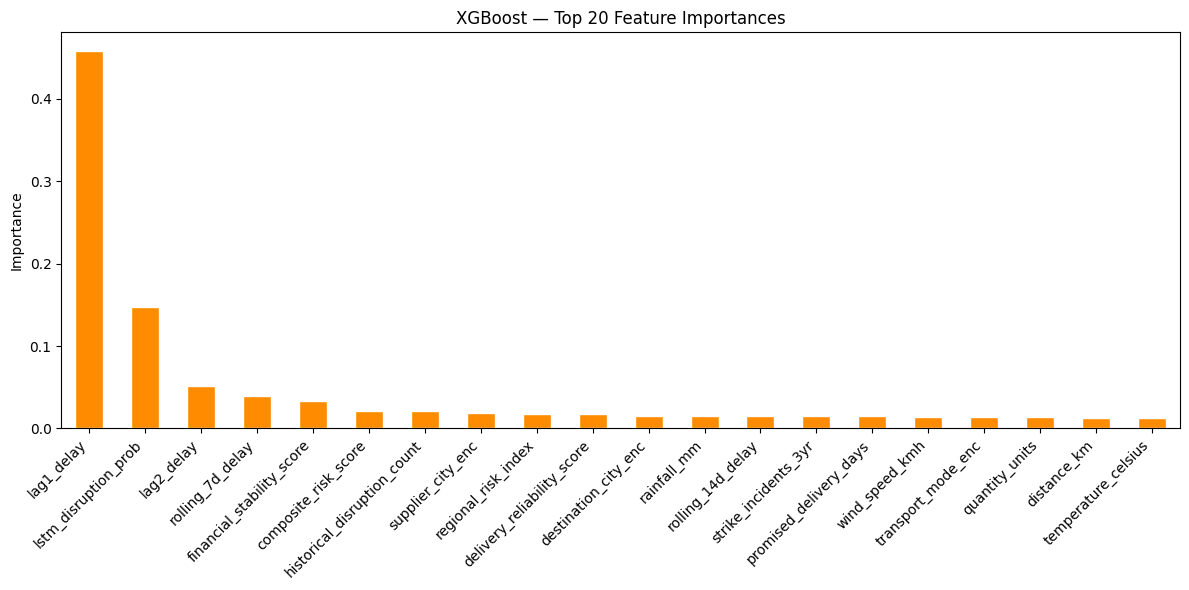


Top 10 features by importance:
lag1_delay                     0.457850
lstm_disruption_prob           0.147883
lag2_delay                     0.051165
rolling_7d_delay               0.039432
financial_stability_score      0.033306
composite_risk_score           0.021223
historical_disruption_count    0.020855
supplier_city_enc              0.018153
regional_risk_index            0.017668
delivery_reliability_score     0.017459
dtype: float32


In [8]:
# Feature importance — top 20
fi = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(12,6))
fi.head(20).plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('XGBoost — Top 20 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('\nTop 10 features by importance:')
print(fi.head(10))

In [9]:
# Save model and feature list
joblib.dump(xgb, MODELS_DIR + 'xgboost_model.pkl')

with open(MODELS_DIR + 'feature_list.json', 'w') as f:
    json.dump(FEATURES, f)

print('✅ xgboost_model.pkl saved.')
print('✅ feature_list.json saved.')
print('\n✅ Notebook 4 (XGBoost) complete.')

✅ xgboost_model.pkl saved.
✅ feature_list.json saved.

✅ Notebook 4 (XGBoost) complete.
